In [1]:
# #! ALL Python modules imported here.
import cv2
import h5py
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader,Dataset
import os
from torchvision import transforms
from PIL import Image
import random
from torch.nn import functional as F
import torchvision
from torchmetrics.image import TotalVariation

import json

In [2]:
VGG19=torchvision.models.vgg19(torchvision.models.VGG19_Weights.IMAGENET1K_V1)
vgg19_feature_extractor=VGG19.features[:35]

c:\Users\sejal\.conda\envs\mldl-nlp\lib\site-packages\torchvision\models\_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


## **All Utilities :**

In [2]:
# #! ALL utilities Here :

# #* Single channels images :
def show_MRI_IMAGE(image:np.array,title: str = 'image'):
    '''input should be (H,W,C=3)'''
    plt.imshow(image,cmap='gray')
    plt.title(f'{title}')
    plt.axis('off')
    plt.show()
    return

# * Save Dataset Functions :
def save_dataset(dataset_name:str,fold_list: list,src:str,dest:str):

    dataset_path=f'{dest}/{dataset_name}'

    os.makedirs(dataset_path,exist_ok=True)

    for fold in fold_list:

        src_folder_path=f'{src}/{fold}'

        dest_folder_path=f'{dataset_path}/{fold}'

        os.makedirs(dest_folder_path,exist_ok=True)

        for file in os.listdir(src_folder_path):

            src_file_path=f'{src_folder_path}/{file}'
            
            dest_file_path=f'{dest_folder_path}/{file}'

            with h5py.File(src_file_path,'r') as f:

                image=f['image'][:]
            
            with h5py.File(dest_file_path,'w') as f:

                f.create_dataset('image',data=image)

    return  True


# * Show the MRI Images :
def show_MRI_images(image1:np.array,image2:np.array,title1:str,title2: str):
    plt.figure()
    image1,image2=np.array(image1),np.array(image2)
    fig,axes=plt.subplots(1,2,figsize=(10,10))
    axes=axes.flatten()

    image1=image1.transpose(1,2,0)
    image1=cv2.resize(image1,(96,96),interpolation=cv2.INTER_CUBIC)
    image2=image2.transpose(1,2,0)


    # up_size=image1.shape[0]*4
    axes[0].imshow(image1,cmap='gray')
    axes[0].set_title(f'{title1}')
    axes[0].axis('off')

    axes[1].imshow(image2,cmap='gray')
    axes[1].set_title(f'{title2}')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()
    



#* upscale the images to (H,W) dimension

def upscale_image(image: np.array ,H:int,W:int,C:int = 3):

    image=np.array(image)

    image=cv2.resize(image.reshape(24,24,3),(96,96),interpolation=cv2.INTER_CUBIC)
    
    return image



#* Gaussian noise function add to images 

def AddGaussianNoise(image: np.array ,mean:int=0 ,std:int=1):

    #* note input image in the -1 to 1 so we have denormalize it.
    image=(image+1)/2
    noise=np.random.normal(mean,std,image.shape)

    image=image+noise

    #* note input image in the -1 to 1 so we have normalize it again.
    image=(image*2-1)

    return image
    

#* function to on/off the model parameter updating
def ON_OFF_Grad(model:torch.nn.Module,switch:str):

    for layer in model.parameters():
        if switch.upper() =='ON':
            layer.requires_grad=True
        else:
            layer.requires_grad=False


#* it save the images to specified location.
def save_MRI_images(image1:np.array,image2:np.array,image3:np.array,title1:str,title2: str,title3:str,image_name:str,fold: str):

    os.makedirs(fold,exist_ok=True)

    plt.figure()
    image1,image2,image3=np.array(image1),np.array(image2),np.array(image3)
    fig,axes=plt.subplots(1,3,figsize=(20,20))
    axes=axes.flatten()
    
    image1=image1.transpose(1,2,0)
    image2=image2.transpose(1,2,0)
    image3=image3.transpose(1,2,0)
    image1=cv2.resize(image1,(96,96),interpolation=cv2.INTER_CUBIC)

    axes[0].imshow(image1,cmap='gray')
    axes[0].set_title(f'{title1}')
    axes[0].axis('off')

    axes[1].imshow(image2,cmap='gray')
    axes[1].set_title(f'{title2}')
    axes[1].axis('off')

    axes[2].imshow(image3,cmap='gray')
    axes[2].set_title(f'{title3}')
    axes[2].axis('off')
    plt.tight_layout()
    plt.savefig(f"./{fold}/{image_name}.png",dpi=300,bbox_inches='tight')
    plt.close(fig=fig)
    return


#* loading the previous state thing :



    


In [3]:
train_data_path=r'NewDataset\data\training'
val_data_path=r'NewDataset\data\validation'
test_data_path=r'NewDataset\data\testing'

In [4]:
for fold in os.listdir(train_data_path):
    # print(fold)
    all_images=os.listdir(os.path.join(train_data_path,fold))
    for image in all_images:

        image_path=os.path.join(train_data_path,fold,image)
        # print(image_path)
        image =cv2.imread(image_path)
        break
    break

image.shape

(240, 240, 3)

In [6]:
image[:,:,0]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

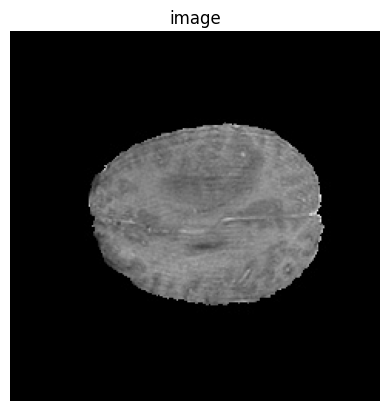

In [7]:
show_MRI_IMAGE(image)

In [8]:
240*240

57600

In [9]:
(image[:,:,0]==image[:,:,1]).sum()

57600

In [10]:
image.shape

(240, 240, 3)

In [11]:
img1=image.transpose(2,0,1)
img1.shape

(3, 240, 240)

In [12]:
img1.transpose(1,2,0).shape

(240, 240, 3)

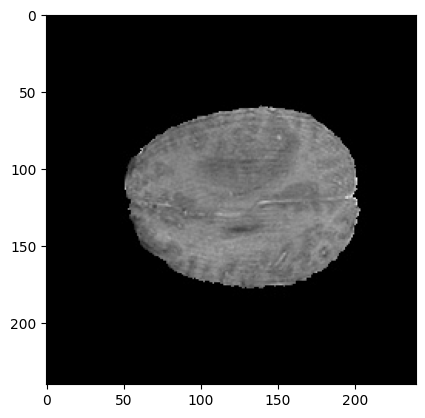

In [13]:
plt.imshow(img1.transpose(1,2,0)[:,:,0],cmap='gray')

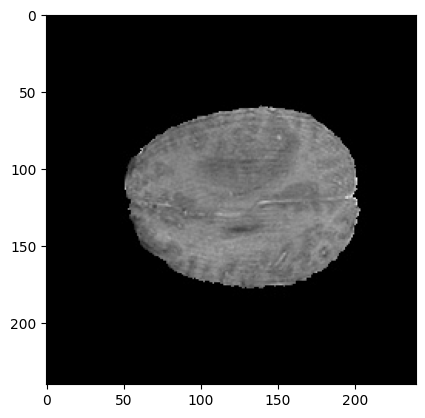

In [14]:
plt.imshow(image.transpose(2,0,1)[2],cmap='gray')

# **Dataset and Dataloader :**

In [15]:
import random

a=[1,2,3,5,5,6]
random.shuffle(a)
a

[2, 5, 3, 5, 6, 1]

In [16]:
class RIRGAN_Dataset(Dataset):

    def __init__(self,dataset_path: str,size:int,add_noise: bool,mean:int=0,std:int=0.0005):

        super().__init__()

        self.all_files=list()
        self.size=size
        self.add_noise=add_noise
        self.mean=mean
        self.std=std

        for vol in os.listdir(dataset_path):

            vol_fold_path=f'{dataset_path}/{vol}'
            for file in os.listdir(vol_fold_path):

                file_path=f'{vol_fold_path}/{file}'
                self.all_files.append(file_path)

        random.shuffle(self.all_files)

    def __len__(self):

        return len(self.all_files)


    def __getitem__(self, index):

        image=cv2.imread(self.all_files[index])
        image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

        offset_x_list=list(range(-2,20))
        offset_y_list=list(range(-5,5))

        offset_x=random.choice(offset_x_list)
        offset_y=random.choice(offset_y_list)

        # offset_x=20
        # offset_y=0

        H,W,_=image.shape

        center_x=W//2
        center_y=H//2

        # image=image[:,:,1] #* index=1 then Te(Enhanced Tumor)

        #^ cropping the images to generate the HR Path:
        size=self.size//2
        hr_image=image[ center_y-size+offset_y :center_y+size+offset_y , center_x-size+offset_x : center_x+size+offset_x ,:]

        lr_image=cv2.resize(hr_image,(self.size//4,self.size//4),interpolation=cv2.INTER_CUBIC)
        H,W,C=hr_image.shape
        hr_image=hr_image.transpose(2,0,1)

        H,W,C=lr_image.shape
        lr_image=lr_image.transpose(2,0,1)

        #* normalization between -1 to 1
        lr_image,hr_image=lr_image.astype(np.float32),hr_image.astype(np.float32)

        #* adding the  noise in the image :
        lr_image=AddGaussianNoise(lr_image,mean=self.mean,std=self.std)

        lr_image,hr_image=torch.from_numpy(lr_image),torch.from_numpy(hr_image)
        lr_image = ((lr_image / 127.5) - 1.0).float()
        hr_image = ((hr_image / 127.5) - 1.0).float()

        return lr_image,hr_image




In [17]:
size=96 #* HR images W/H
train_dataset=RIRGAN_Dataset(train_data_path,size,add_noise=True)
print(f'Training LR Images Shape :{train_dataset.__getitem__(0)[0].shape}')
print(f'Training HR Images Shape :{train_dataset.__getitem__(0)[1].shape}')
LR_image,HR_image=train_dataset.__getitem__(1)[0],train_dataset.__getitem__(1)[1]

Training LR Images Shape :torch.Size([3, 24, 24])
Training HR Images Shape :torch.Size([3, 96, 96])


In [18]:
np.array(LR_image)

array([[[-0.20784234, -0.19998497, -0.19999453, ..., -0.26273835,
         -0.20783456, -0.20784822],
        [-0.18431135, -0.16864602, -0.24706937, ..., -0.18431187,
         -0.15292999, -0.20785223],
        [-0.20785178, -0.18430409, -0.24705257, ..., -0.16077623,
         -0.21569383, -0.27059022],
        ...,
        [-0.40392599, -0.27843377,  0.41961765, ..., -0.2392233 ,
         -0.27842063, -0.24706322],
        [-0.35686952, -0.37256333,  0.03529519, ..., -0.24707071,
         -0.27842942, -0.27842367],
        [-0.24705993, -0.18430762,  0.35687098, ..., -0.26275298,
         -0.31766146, -0.41176984]],

       [[-0.20784627, -0.2000063 , -0.20001018, ..., -0.26275653,
         -0.20783919, -0.20783122],
        [-0.18431486, -0.16861619, -0.24706991, ..., -0.18430784,
         -0.15295209, -0.20784594],
        [-0.20786034, -0.18431102, -0.24705836, ..., -0.16078803,
         -0.21569563, -0.27059168],
        ...,
        [-0.40391704, -0.27843824,  0.41961625, ..., -

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.14997134..1.017877].


<Figure size 640x480 with 0 Axes>

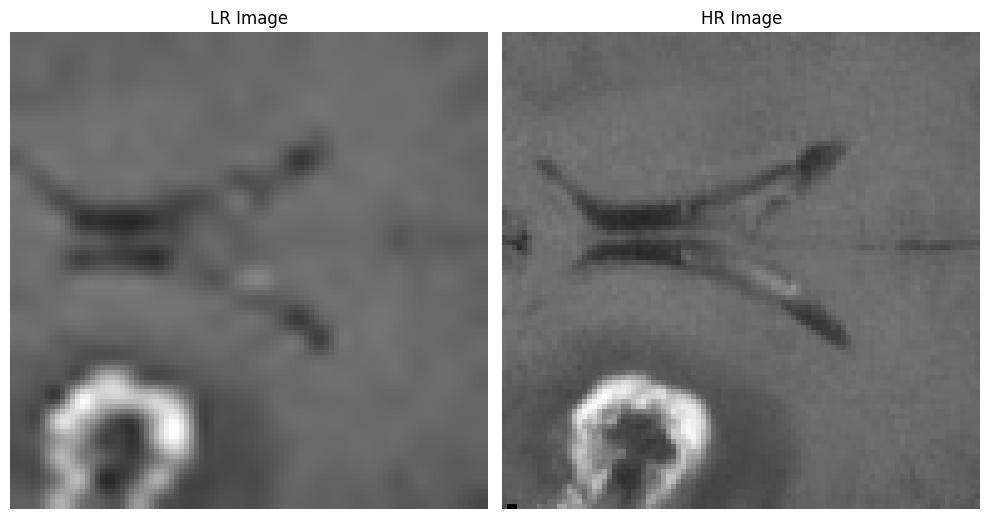

In [19]:
show_MRI_images(
    image1=(LR_image+1)/2,
    image2=(HR_image+1)/2,
    title1='LR Image',
    title2='HR Image'
)

In [20]:
# #! Dataset Path :
train_dataset_path=train_data_path
test_dataset_path=test_data_path
val_dataset_path=val_data_path

train_val_size=96
test_size=128
batch_size=16

train_dataset=RIRGAN_Dataset(train_dataset_path,train_val_size,add_noise=True)
val_dataset=RIRGAN_Dataset(val_dataset_path,train_val_size,add_noise=True)

test_dataset=RIRGAN_Dataset(test_dataset_path,test_size,add_noise=True)


test_dataset.__getitem__(0)[0].shape

torch.Size([3, 32, 32])

In [21]:
# #* DataLoader :
batch_size=16 #* from the paper


train_loader=DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

val_loader=DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

test_loader=DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=True,
)

In [22]:
# #* testing the dataloader

print(f'Total Batch in Training : {len(train_loader)}')
print(f'Total Batch in Validation : {len(val_loader)}')
print(f'Total Batch in Testing : {len(test_loader)}')

Total Batch in Training : 1406
Total Batch in Validation : 285
Total Batch in Testing : 191


In [23]:
LR_Images,HR_Images=next(iter(test_loader))

print(f'LR Images Shape :{LR_Images.shape}')
print(f'HR Images Shape :{HR_Images.shape}')

LR Images Shape :torch.Size([16, 3, 32, 32])
HR Images Shape :torch.Size([16, 3, 128, 128])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.09223827..0.67059433].


<Figure size 640x480 with 0 Axes>

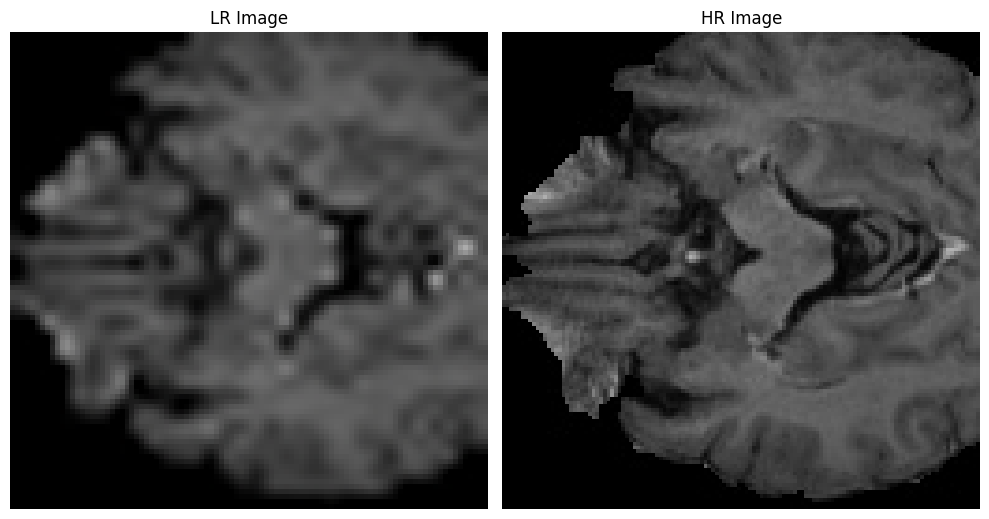

In [24]:
show_MRI_images(
    (LR_Images[4]+1)/2,
    (HR_Images[4]+1)/2,
    "LR Image",
    "HR Image"
)

# **Model Architecture :**

## **1.Enhanced Residual Block :**

In [ ]:
class EResidualBlock(nn.Module):

    def __init__(self,in_channels:int,out_channels:int,kernel_size:int ):
        super().__init__()

        self.conv1=nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            padding='same',
            stride=1
        )

        self.PRelu=nn.PReLU()

        self.conv2=nn.Conv2d(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            padding='same',
            stride=1
        )

        

    def forward(self,inputs):

        output=self.conv1(inputs)

        output=self.PRelu(output)

        output=self.conv2(output)

        output=output+inputs  #* Here output and input should have the same dimension

        return output



## **2.RIR-Block :**

In [26]:
class RIRBlock(nn.Module):

    def __init__(self,in_channels:int,out_channels: int ,kernel_size:int,num_of_ERes_block:int,alpha:int):
        super().__init__()
        self.alpha=alpha
        self.RIR_Block=nn.Sequential(
            *[
                EResidualBlock(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    kernel_size=kernel_size
                )
                for _ in range(num_of_ERes_block)
            ]
        )

    def forward(self,inputs):

        output=self.RIR_Block(inputs)

        output=inputs + (self.alpha) * output

        return output

## **3.SubPixelLayer :**

In [27]:
class SubPixelLayer(nn.Module):
    def __init__(self,in_channels:int,out_channels:int,kernel_size:int,scale:int):

        super().__init__()
        
        self.conv=nn.Conv2d(
            in_channels=in_channels, #* 64
            out_channels=out_channels, #* 256
            kernel_size=kernel_size,
            padding='same',
            stride=1
        )

        self.pixelShuffler=nn.PixelShuffle(upscale_factor=scale) #* it enlarge the input image in height and weight by putting the missing pixel from the higher subpixel space 

        self.PRelu=nn.PReLU()
        

    def forward(self,inputs):

        output=self.conv(inputs)

        output=self.pixelShuffler(output)

        output=self.PRelu(output)

        return output



## **4.RIRG-Input Layer :**

In [28]:
class RIRGInputLayer(nn.Module):

    def __init__(self, in_channels:int,out_channels: int,kernel_size: int):
        super().__init__()

        self.conv=nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            padding='same',
            stride=1
        )

        self.PRelu=nn.PReLU()

    def forward(self,inputs):
        
        output=self.conv(inputs)
        output=self.PRelu(output)
        return output


## **5.RIRG-Output Layer :**

In [29]:
class RIRGOutputLayer(nn.Module):

    def __init__(self,in_channels:int,out_channels:int,kernel_size: int):
        super().__init__()

        self.conv=nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            padding='same',
            stride=1
        )

        self.tanh=nn.Tanh()

    
    def forward(self,inputs):
        
        output=self.conv(inputs)

        output=self.tanh(output)
        
        return output

## **6. RIRG:**

In [30]:
class RIRG(nn.Module):

    def __init__(self,in_channel:int,out_channel:int,in_RIR_block_channel:int,
                kernel_size_in_out_layer:int,kerne_size_RIR_block:int,no_of_RIR_Block:int,no_of_ERes_block:int,
                sub_PixelLayer_channel:int,alpha:int,scale:int):
        super().__init__()

        self.inputLayer=RIRGInputLayer(
            in_channels=in_channel,
            out_channels=in_RIR_block_channel,
            kernel_size=kernel_size_in_out_layer
        )

        self.FeatureExtractionLayer=nn.Sequential(
            *[
                RIRBlock(
                    in_channels=in_RIR_block_channel,
                    out_channels=in_RIR_block_channel,
                    kernel_size=kerne_size_RIR_block,
                    num_of_ERes_block=no_of_ERes_block,
                    alpha=alpha
                )
                for _ in range(no_of_RIR_Block)
            ]
        )

        self.conv=nn.Conv2d(
            in_channels=in_RIR_block_channel,
            out_channels=in_RIR_block_channel,
            kernel_size=kerne_size_RIR_block,
            padding='same',
            stride=1
        )

        self.SubPixelLayer1=SubPixelLayer(
            in_channels=in_RIR_block_channel,
            out_channels=sub_PixelLayer_channel,
            kernel_size=kerne_size_RIR_block,
            scale=scale
        )
        self.SubPixelLayer2=SubPixelLayer(
            in_channels=in_RIR_block_channel,
            out_channels=sub_PixelLayer_channel,
            kernel_size=kerne_size_RIR_block,
            scale=2
        )

        self.OutputLayer=RIRGOutputLayer(
            in_channels=in_RIR_block_channel,
            out_channels=out_channel,
            kernel_size=kernel_size_in_out_layer
        )

    def forward(self,inputs):
        
        #* input layer
        out_inputLayer=self.inputLayer(inputs)

        #* feature extraction layer :

        out_featureExtra_layer=self.FeatureExtractionLayer(out_inputLayer)

        #* conv layer :

        out_conv_layer=self.conv(out_featureExtra_layer)

        #* Global Residual connection : (GSC-Global Skip Connection)

        out_GSC=out_conv_layer+out_inputLayer

        #* Sub Pixel Layer(Enlarge Layer)

        out_pixel_layer1=self.SubPixelLayer1(out_GSC)
        out_pixel_layer2=self.SubPixelLayer2(out_pixel_layer1)

        #* Output Layer (Regenerator Layer)

        output=self.OutputLayer(out_pixel_layer2)

        return output


In [31]:
# test=RIRG(
#     in_channel=3,
#     out_channel=3,
#     in_RIR_block_channel=64,
#     kernel_size_in_out_layer=9,
#     kerne_size_RIR_block=3,
#     no_of_RIR_Block=8,
#     no_of_ERes_block=5,
#     sub_PixelLayer_channel=256,
#     alpha=0.2,
#     scale=2   
# )

# test(LR_Images).shape

# **RaD-Discriminator :**

## **1. RaDInput Layer :**

In [32]:
class RadInputLayer(nn.Module):

    def __init__(self,in_channels:int,out_channels:int,kernel_size:int):
        super().__init__()

        self.conv=nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=1,
            padding='same'
        )

        self.LRelu=nn.LeakyReLU()
    


    def forward(self,inputs):
        
        output=self.conv(inputs)

        output=self.LRelu(output)

        return output

## **2.RaDRepeat Block :**

In [33]:
class RadRepeatBlock(nn.Module):

    def __init__(self,in_channels:int,out_channels:int,kernel_size:int ,stride: int):
        super().__init__()

        self.conv=nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride
        )

        self.BNLayer=nn.BatchNorm2d(
            num_features=out_channels,
        )

        self.LRelu=nn.LeakyReLU()
    
    def forward(self,inputs):
        
        output=self.conv(inputs)

        output=self.BNLayer(output)

        output=self.LRelu(output)

        return output

## **3.Output Layer :**

In [34]:
class RadOutputLayer(nn.Module):

    def __init__(self,in_features_1:int,out_features_1:int,out_features_2:int,bias: bool = False ):
        super().__init__()

        self.Dense1=nn.Linear(
            in_features=in_features_1,
            out_features=out_features_1,
            bias=bias,
        )

        self.LRelu=nn.LeakyReLU()

        self.Dense2=nn.Linear(
            in_features=out_features_1,
            out_features=out_features_2,
            bias=bias
        )
    
    def forward(self,inputs):

        output=self.Dense1(inputs)

        output=self.LRelu(output)

        output=self.Dense2(output)
        
        return output


## **4.RaD :**

In [35]:
class Rad(nn.Module):

    def __init__(self,params: dict ):
        super().__init__()

        self.InputLayer=RadInputLayer(
            in_channels=params['input_layer']['input_channel'],
            out_channels=params['input_layer']['num_of_channels'],
            kernel_size=params['input_layer']['k']
            
        )

        self.InnerLayer=nn.Sequential(
            *[
                RadRepeatBlock(
                    in_channels=param['input_channel'],
                    out_channels=param['num_of_channels'],
                    kernel_size=param['k'],
                    stride=param['stride']
                )
                for  ind,(name,param) in enumerate(params.items()) if ind in range(1,8)
            ]
        )

        self.FlattenLayer=nn.Flatten()

        self.OutPutLayer=RadOutputLayer(
            in_features_1=params['RadOutput']['input_features_1'],
            out_features_1=params['RadOutput']['output_features_1'],
            out_features_2=params['RadOutput']['output_features_2']
        )

    
    def forward(self,inputs):
        

        output=self.InputLayer(inputs)
        output=self.InnerLayer(output)
        output=self.FlattenLayer(output)
        output=self.OutPutLayer(output)

        return  output



In [36]:
params={
    'input_layer':{
        'input_channel':3,
        'k':3,
        'num_of_channels':64,
        'stride':1
    },
    'Rad_Repeat_block1':{
        'input_channel':64,
        'k':3,
        'num_of_channels':64,
        'stride':2
    },
    'Rad_Repeat_block2':{
        'input_channel':64,
        'k':3,
        'num_of_channels':128,
        'stride':1
    },
    'Rad_Repeat_block3':{
        'input_channel':128,
        'k':3,
        'num_of_channels':128,
        'stride':2
    },
    'Rad_Repeat_block4':{
        'input_channel':128,
        'k':3,
        'num_of_channels':256,
        'stride':1
    },
    'Rad_Repeat_block5':{
        'input_channel':256,
        'k':3,
        'num_of_channels':256,
        'stride':2
    },
    'Rad_Repeat_block6':{
        'input_channel':256,
        'k':3,
        'num_of_channels':512,
        'stride':1
    },
    'Rad_Repeat_block7':{
        'input_channel':512,
        'k':3,
        'num_of_channels':512,
        'stride':2
    },
    'RadOutput':{
        'input_features_1':4608,
        'output_features_1':1024,
        'output_features_2':1,
    },
}

In [37]:
# HR_Images=HR_Images.to('cpu')
# test=Rad(params)

# test(HR_Images)

# **Training Process :**

# **1.Define All Losses :**

## **A) RaD Loss :**

In [38]:
def RaDLossFun(HR_Output:torch.Tensor,SR_Output:torch.Tensor ,device:torch.device='cpu'):

    #* Mean values :
    avg_sr_output=SR_Output.mean()
    avg_hr_output=HR_Output.mean()

    #* finding the relative score :

    relative_real_fake=HR_Output-avg_sr_output
    relative_fake_real=SR_Output-avg_hr_output


    # loss=((-1*(relative_real_fake.log() + (1-relative_fake_real).log())).sum())/HR_Output.shape[0]
    
    #* RaD want to increase the relative_real_fake ie . how much real image look real than fake
    loss_real=F.binary_cross_entropy_with_logits(
        input=relative_real_fake,
        target=torch.ones_like(HR_Output).to(device) #^ therefor it is one ie. avg(log(relative_real_fake))
    )

    #* RaD want to decrease the relative_fake_real ie. how much fake image look to real relative to real.
    loss_fake=F.binary_cross_entropy_with_logits(
        input=relative_fake_real,
        target=torch.zeros_like(SR_Output).to(device) #^ therefor it is zero  ie. avg(log(1-relative_fake_real))
    )



    return (loss_real+loss_fake)
    

## **B) Generator Loss :**

### **1.Adversarial Loss :**
    **1.Goal of this loss to Make the Model to generate the Fake Image Look to Real**
    **2.In Mathematically : Decrease the avg diff between real and fake**

In [39]:
def RIRGAdversarialLoss(HR_Output:torch.Tensor,SR_Output:torch.Tensor,device:torch.device = 'cpu'):

    #* Mean values :
    avg_hr_output=HR_Output.mean()
    avg_sr_output=SR_Output.mean()

    #* finding the relative score :

    relative_real_fake=HR_Output-avg_sr_output
    relative_fake_real=SR_Output-avg_hr_output

    #* loss

    # loss=((((1-relative_real_fake).log() + relative_fake_real.log()) * -1).sum())/HR_Output.shape[0]

    #* loss real

    #^ generator want to generate more realistic images so ie. is have to decrease relative_real_fake ie. fake images look like real images :
    loss_real=F.binary_cross_entropy_with_logits(
        input=relative_real_fake,
        target=torch.zeros_like(HR_Output).to(device)  #^ ie. avg(log(1-relative_real_fake)) ↑↑↑↑↑
    )

    #* loss fake
    #^ generate want to generate fake image looks real so it have to increase relative_fake_real ie.
    loss_fake=F.binary_cross_entropy_with_logits(
        input=relative_fake_real,
        target=torch.ones_like(SR_Output).to(device) #^ ie. avg(log(relative_fake_real))  ↑↑↑↑↑
    )


    return (loss_real+loss_fake)



### **2.Pixel Loss :**
    -it is Mean Absolute Difference between the two pixel of SR and HR.
    -it help to gain the structure and reduce the loss.

In [40]:

def RIRPixelLoss(HR_Images:torch.Tensor,SR_Images:torch.Tensor):
    
    (B,C,H,W)=HR_Images.shape
    total_pixel=B*C*H*W

    loss=torch.abs(SR_Images-HR_Images).sum()/total_pixel

    return loss


### **3.Perceptual Loss**
    - it help to improves the visual quality.
    - it uses VGG19 to extract the Feature in Higher Dimensional Feature Space and compare there SR and HR.
    - ie. it compare is this both image are similar and find the similarity score

#### **Note:**
    - VGG19 requires input in 0 to 1 
    - input images must be normalized using specific mean and standard deviation values. 
    - mean = [0.485, 0.456, 0.406]
    - std =  [0.229, 0.224, 0.225]
    

In [41]:

def vgg_normalize(x,device:torch.device ='cpu'):

    imagenet_mean = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1).to(device)
    imagenet_std  = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1).to(device)

    return (x-imagenet_mean)/imagenet_std

In [42]:
def RIRPerceptualLoss(SR_Images:torch.Tensor,HR_Images:torch.Tensor,vgg19_feature_extractor:torch.nn.Module,
                    device:torch.device='cpu'):

    sr_higher_feature_dim_space=vgg19_feature_extractor(vgg_normalize(((SR_Images + 1)/2),device=device))
    hr_higher_feature_dim_space=vgg19_feature_extractor(vgg_normalize(((HR_Images + 1)/2),device=device))

    perceptual_loss=((sr_higher_feature_dim_space-hr_higher_feature_dim_space) **2).mean()

    return perceptual_loss


### **4.Total Variation Loss (TV)**
    - it calculate the change in nearby pixel density.
    - it value high in the noise.
    - it is use to remove the nose.
    

In [43]:
def RIRTotalVariation(Images:torch.Tensor,fun:TotalVariation,device:torch.device='cpu'):

    return fun(Images.to(device))

In [44]:
# #* System Information :
for i in range(torch.cuda.device_count()):
    properties=torch.cuda.get_device_properties(i)
    print(f"GPU {i}: {properties.name} | Memory: {properties.total_memory / 1e9:.2f} GB")

torch.cuda.set_device(0)

GPU 0: NVIDIA GeForce RTX 4050 Laptop GPU | Memory: 6.44 GB


In [45]:
properties

_CudaDeviceProperties(name='NVIDIA GeForce RTX 4050 Laptop GPU', major=8, minor=9, total_memory=6140MB, multi_processor_count=20, uuid=eb965217-a78a-2653-c9c0-158ac07e31a3, L2_cache_size=24MB)

# **2.PreTraining (Generator) :**

In [46]:
stop

NameError: name 'stop' is not defined

In [ ]:
import json
#^ Generator Parameters :
total_losses_RIR_G_train=list()
total_losses_RIR_G_val=list()

losses_pixel_train=list()
losses_pixel_val=list()

losses_perceptual_train=list()
losses_perceptual_val=list()

file_path=f'gen_train_val_loss2_110_noise.json'

with open(file_path,'r') as f:

    json_file=json.load(f)
    # print(json_file)

#* appending the loaded value :

total_losses_RIR_G_train.extend(json_file['train']['total_losses_RIR_G_train'])
losses_pixel_train.extend(json_file['train']['losses_pixel_train'])
losses_perceptual_train.extend(json_file['train']['losses_perceptual_train'])


total_losses_RIR_G_val.extend(json_file['val']['total_losses_RIR_G_val'])
losses_perceptual_val.extend(json_file['val']['losses_perceptual_val'])
losses_pixel_val.extend(json_file['val']['losses_pixel_val'])


START=101
END=300



In [ ]:
# #* Model's ie. Generator and Discriminator Initialization :

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.set_device(0)

gen = RIRG(
    in_channel=3,
    out_channel=3,
    in_RIR_block_channel=64,
    kernel_size_in_out_layer=9,
    kerne_size_RIR_block=3,
    no_of_RIR_Block=8,
    no_of_ERes_block=5,
    sub_PixelLayer_channel=256,
    alpha=0.2,
    scale=2,
)
gen.load_state_dict(torch.load("generator2_noise_110.pth"))


vgg19_feature_extractor = VGG19.features[:35]

ON_OFF_Grad(vgg19_feature_extractor, "OFF")

gen.to(device)
vgg19_feature_extractor.to(device)

# * Optimizer Initialization and Loss function's

optimizer_gen = torch.optim.Adam(gen.parameters(), lr=1e-4, betas=(0.9, 0.999))


optimizer_gen.load_state_dict(torch.load("generator_optimizer2_noise_110.pth"))

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer=optimizer_gen, step_size=20, gamma=0.5
)

scheduler.load_state_dict(torch.load("generator2_scheduler_noise_110.pth"))

# * training and validation loss list and EPOCHs Initialization
EPOCHS = 150


# * for each EPOCH

for epoch in range(START, END + 1):

    # &--------------------------------- RIR-G (Generator ) Training :-----------------------------------------

    # ^ freezing the Dis and unfreezing the Gen.
    gen.train()

    # * iterating on all batches :
    running_total_loss_RIR_G_train = 0.0
    running_loss_pixel_train = 0.0
    running_loss_perceptual_train = 0.0

    for LR_Images, HR_Images in train_loader:

        LR_Images, HR_Images = LR_Images.to(device), HR_Images.to(device)

        # ^ optimizer_dis : gradient clear
        optimizer_gen.zero_grad()

        # ^ forward pass :

        SR_Images = gen(LR_Images)

        # ^ Loss Calculation : 4 type of loss :

        # ^ 1.Pixel Loss :

        loss_pixel_train_batch = RIRPixelLoss(HR_Images=HR_Images, SR_Images=SR_Images)
        running_loss_pixel_train += loss_pixel_train_batch.item()

        # ^ 2.Perceptual Loss :

        loss_perceptual_train_batch = RIRPerceptualLoss(
            SR_Images=SR_Images,
            HR_Images=HR_Images,
            vgg19_feature_extractor=vgg19_feature_extractor,
            device=device,
        )

        running_loss_perceptual_train += loss_perceptual_train_batch.item()

        # ^ Total Loss :

        total_loss_RIR_G_train_batch = (
            loss_pixel_train_batch + loss_perceptual_train_batch * 0.01
        )

        running_total_loss_RIR_G_train += total_loss_RIR_G_train_batch.item()

        # ^ Gradient Calculation for RIR-G
        total_loss_RIR_G_train_batch.backward()

        # ^ Weight Updating of RIR-G

        optimizer_gen.step()

    total_loss_RIR_G_train = running_total_loss_RIR_G_train / len(train_loader)
    loss_pixel_train = running_loss_pixel_train / len(train_loader)
    loss_perceptual_train = running_loss_perceptual_train / len(train_loader)

    total_losses_RIR_G_train.append(total_loss_RIR_G_train)
    losses_pixel_train.append(loss_pixel_train)
    losses_perceptual_train.append(loss_perceptual_train)

    # * -------------------------------------- Validation ------------------------------------------------------
    gen.eval()

    with torch.no_grad():

        running_total_loss_RIR_G_val = 0.0
        running_loss_pixel_val = 0.0
        running_loss_perceptual_val = 0.0

        # ^ for each batch in the validation loader :
        for LR_Images, HR_Images in val_loader:

            LR_Images, HR_Images = LR_Images.to(device), HR_Images.to(device)

            # * forward pass of generator  :

            SR_Images = gen(LR_Images)

            # * Loss Calculation :

            # & RIR-G loss :

            # ^ 1.Pixel Loss :

            loss_pixel_val_batch = RIRPixelLoss(
                HR_Images=HR_Images, SR_Images=SR_Images
            )
            running_loss_pixel_val += loss_pixel_val_batch.item()

            # ^ 2.Perceptual Loss :

            loss_perceptual_val_batch = RIRPerceptualLoss(
                SR_Images=SR_Images,
                HR_Images=HR_Images,
                vgg19_feature_extractor=vgg19_feature_extractor,
                device=device,
            )

            running_loss_perceptual_val += loss_perceptual_val_batch.item()

            # ^ Total Loss :

            total_loss_RIR_G_val_batch = (
                loss_pixel_val_batch + loss_perceptual_val_batch * 0.01
            )

            running_total_loss_RIR_G_val += total_loss_RIR_G_val_batch.item()

    total_loss_RIR_G_val = running_total_loss_RIR_G_val / len(val_loader)
    loss_pixel_val = running_loss_pixel_val / len(val_loader)
    loss_perceptual_val = running_loss_perceptual_val / len(val_loader)

    total_losses_RIR_G_val.append(total_loss_RIR_G_val)
    losses_pixel_val.append(loss_pixel_val)
    losses_perceptual_val.append(loss_perceptual_val)

    # ^ ----------------------------------------- Saving Image Per Epochs -----------------------------------------------
    with torch.no_grad():

        LR_Images, HR_Images = next(iter(val_loader))
        LR_Images, HR_Images = LR_Images.to(device), HR_Images.to(device)
        SR_Images = gen(LR_Images)

        SR_Images, LR_Images, HR_Images = (
            SR_Images.to("cpu"),
            LR_Images.to("cpu"),
            HR_Images.to("cpu"),
        )

        save_MRI_images(
            (LR_Images[0] + 1) / 2,
            (SR_Images[0] + 1) / 2,
            (HR_Images[0] + 1) / 2,
            title1="LR",
            title2="SR",
            title3="HR",
            image_name=f"/{epoch}.png",
            fold="Training_Images2_NOISE",
        )

    if epoch > 150:
        EPOCHS = 200
    elif epoch > 200:
        EPOCHS = 250
    elif epoch > 250:
        EPOCHS = 300

    torch.save(gen.state_dict(), f"./GAN2_110_Noise/generator2_noise_{EPOCHS}.pth")
    torch.save(
        optimizer_gen.state_dict(),
        f"./GAN2_110_Noise/generator_optimizer2_noise_{EPOCHS}.pth",
    )
    torch.save(
        scheduler.state_dict(),
        f"./GAN2_110_Noise/generator2_scheduler_noise_{EPOCHS}.pth",
    )
    # * Update the learning rate after a epoch:
    scheduler.step()

    print(
        f"Epoch : {epoch}/{END} \n\t\t | Training Generator Total_loss : {total_loss_RIR_G_train} , Validation Generator Total_loss : {total_loss_RIR_G_val} |"
    )

Epoch : 101/301 
		 | Training Generator Total_loss : 0.059047145925324465 , Validation Generator Total_loss : 0.05966305178508424 |
Epoch : 102/301 
		 | Training Generator Total_loss : 0.05902381375389621 , Validation Generator Total_loss : 0.05973187192228802 |
Epoch : 103/301 
		 | Training Generator Total_loss : 0.059089426155259056 , Validation Generator Total_loss : 0.05966976904555371 |
Epoch : 104/301 
		 | Training Generator Total_loss : 0.059029097407844296 , Validation Generator Total_loss : 0.05983298430055903 |


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.07602403..0.9232586].


Epoch : 105/301 
		 | Training Generator Total_loss : 0.059072816831882445 , Validation Generator Total_loss : 0.059790785035543276 |


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.032292705..0.7306504].


Epoch : 106/301 
		 | Training Generator Total_loss : 0.05902659642651868 , Validation Generator Total_loss : 0.05951917168864033 |


...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:


data={
    'train':{
        'total_losses_RIR_G_train':total_losses_RIR_G_train,
        'losses_pixel_train':losses_pixel_train,
        'losses_perceptual_train':losses_perceptual_train
    },
    'val':{
        'total_losses_RIR_G_val':total_losses_RIR_G_val,
        'losses_pixel_val':losses_pixel_val,
        'losses_perceptual_val':losses_perceptual_val

    }
}

with open('./GAN2_110_Noise/gen_train_val_loss2_300_noise.json','w') as f:

    json.dump(data,f,indent=4)


    torch.save(gen.state_dict(), f"./GAN2_110_Noise/generator2_noise_{300}.pth")
    torch.save(
        optimizer_gen.state_dict(),
        f"./GAN2_110_Noise/generator_optimizer2_noise_{300}.pth",
    )
    torch.save(
        scheduler.state_dict(),
        f"./GAN2_110_Noise/generator2_scheduler_noise_{300}.pth",
    )

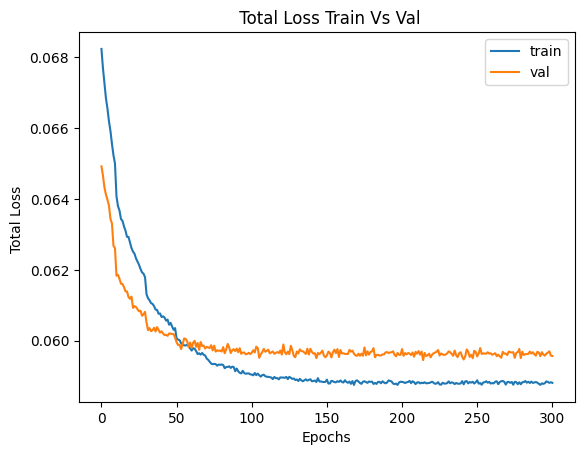

In [ ]:
plt.figure()
plt.plot(total_losses_RIR_G_train,label='train')
plt.plot(total_losses_RIR_G_val,label='val')
plt.legend()
plt.title(" Total Loss Train Vs Val")
plt.xlabel("Epochs")
plt.ylabel("Total Loss ")
plt.show()

Text(0, 0.5, 'Pixel Loss ')

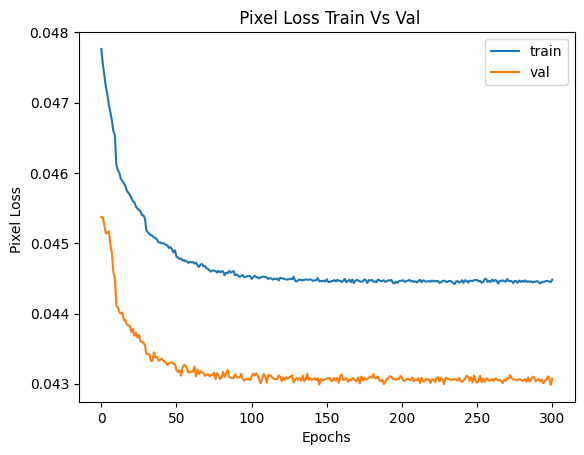

In [ ]:
plt.figure()
plt.plot(losses_pixel_train,label='train')
plt.plot(losses_pixel_val,label='val')
plt.legend()
plt.title(" Pixel Loss Train Vs Val")
plt.xlabel("Epochs")
plt.ylabel("Pixel Loss ")

Text(0, 0.5, 'Perceptual Loss ')

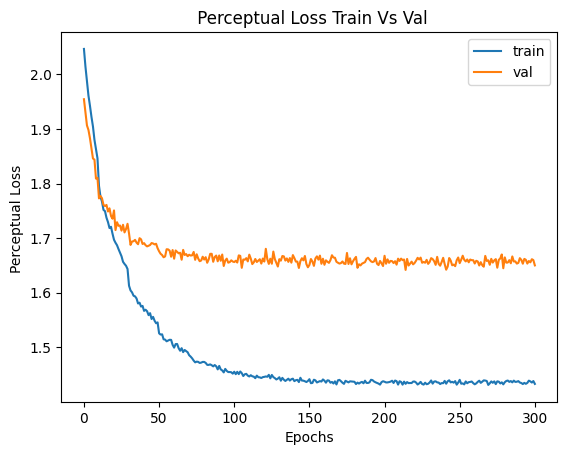

In [ ]:
plt.figure()
plt.plot(losses_perceptual_train,label='train')
plt.plot(losses_perceptual_val,label='val')
plt.legend()
plt.title(" Perceptual Loss Train Vs Val")
plt.xlabel("Epochs")
plt.ylabel("Perceptual Loss ")

In [ ]:
stop

# **2.GAN Training :**

#### **Loading the Pretrain Generator :**

In [ ]:
gen=RIRG(
    in_channel=3,
    out_channel=3,
    in_RIR_block_channel=64,
    kernel_size_in_out_layer=9,
    kerne_size_RIR_block=3,
    no_of_RIR_Block=8,
    no_of_ERes_block=5,
    sub_PixelLayer_channel=256,
    alpha=0.2,
    scale=2   
)

gen.load_state_dict(torch.load('./GAN2_110_Noise/generator2_noise_300.pth'))


<All keys matched successfully>

In [ ]:
dis=Rad(params)

In [ ]:
# #* Model's ie. Generator and Discriminator Initialization :

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.set_device(0)


vgg19_feature_extractor = VGG19.features[:35]

ON_OFF_Grad(vgg19_feature_extractor, "OFF")

gen.to(device)
dis.to(device)
vgg19_feature_extractor.to(device)

# * Optimizer Initialization and Loss function's

optimizer_gen = torch.optim.Adam(gen.parameters(), lr=1e-6, betas=(0.5, 0.999))

optimizer_dis = torch.optim.Adam(dis.parameters(), lr=1e-8, betas=(0.5, 0.99))

# LAMBDA=0.006
# GAMMA=1
# BETA=2e-9
# ETA=5e-3

LAMBDA =1
GAMMA = 0.01
BETA = 2e-9
ETA = 5e-3

totalVariationLoss = TotalVariation().to(device)

scheduler_gen = torch.optim.lr_scheduler.StepLR(
    optimizer=optimizer_gen, step_size=50, gamma=0.2
)

scheduler_dis = torch.optim.lr_scheduler.StepLR(
    optimizer=optimizer_dis, step_size=50, gamma=0.2
)

# * training and validation loss list and EPOCHs Initialization
START = 0
END = 200
EPOCHS = 50
# ^ Generator Parameters :
total_losses_RIR_G_train = list()
total_losses_RIR_G_val = list()

losses_pixel_train = list()
losses_pixel_val = list()

losses_perceptual_train = list()
losses_perceptual_val = list()

losses_adversarial_train = list()
losses_adversarial_val = list()

losses_totalVariation_train = list()
losses_totalVariation_val = list()


# ^ Discriminator Parameters :

losses_RaD_train = list()
losses_RaD_val = list()


# * for each EPOCH

for epoch in range(START, END + 1):

    # * -------------------------------- Training ----------------------------------------

    # &----------------- ---------------Training of RAD : -----------------------------------

    # ^ freezing the Gen and unfreezing the Dis.

    gen.eval()
    dis.train()
    ON_OFF_Grad(gen, "OFF")
    ON_OFF_Grad(dis, "ON")
    running_loss_RaD_train = 0.0

    # * iterating on all batches :

    for LR_Images, HR_Images in train_loader:

        LR_Images, HR_Images = LR_Images.to(device), HR_Images.to(device)

        # ^ optimizer_dis : gradient clear
        optimizer_dis.zero_grad()

        # ^ forward pass :
        # * 1. Gen
        with torch.no_grad():
            SR_Images = gen(LR_Images)

        # * 2. Dis

        sr_output = dis(SR_Images)
        hr_output = dis(HR_Images)

        # ^ Loss Calculation :

        loss_RaD_train_batch = RaDLossFun(
            HR_Output=hr_output, SR_Output=sr_output, device=device
        )

        running_loss_RaD_train += loss_RaD_train_batch.item()

        # ^ Gradient Calculation for RaD
        loss_RaD_train_batch.backward()

        # ^ Weight Updating of RaD.

        optimizer_dis.step()

    loss_RaD_train = running_loss_RaD_train / len(train_loader)

    losses_RaD_train.append(loss_RaD_train)

    # &------------------------- RIR-G (Generator ) Training :---------------------------------

    # ^ freezing the Dis and unfreezing the Gen.
    gen.train()
    dis.eval()
    ON_OFF_Grad(gen, "ON")
    ON_OFF_Grad(dis, "OFF")

    # * iterating on all batches :
    running_total_loss_RIR_G_train = 0.0
    running_loss_pixel_train = 0.0
    running_loss_perceptual_train = 0.0
    running_loss_adversarial_train = 0.0
    running_loss_totalVariation_train = 0.0

    for LR_Images, HR_Images in train_loader:

        LR_Images, HR_Images = LR_Images.to(device), HR_Images.to(device)

        # ^ optimizer_dis : gradient clear
        optimizer_gen.zero_grad()

        # ^ forward pass :

        # * 1. Gen

        SR_Images = gen(LR_Images)

        # * 2. Dis

        sr_output = dis(SR_Images)
        hr_output = dis(HR_Images)

        # ^ Loss Calculation : 4 type of loss :

        # ^ 1.Pixel Loss :

        loss_pixel_train_batch = RIRPixelLoss(HR_Images=HR_Images, SR_Images=SR_Images)
        running_loss_pixel_train += loss_pixel_train_batch.item()

        # ^ 2.Perceptual Loss :

        loss_perceptual_train_batch = RIRPerceptualLoss(
            SR_Images=SR_Images,
            HR_Images=HR_Images,
            vgg19_feature_extractor=vgg19_feature_extractor,
            device=device,
        )

        running_loss_perceptual_train += loss_perceptual_train_batch.item()

        # ^ 3.Adversarial Loss :

        loss_adversarial_train_batch = RIRGAdversarialLoss(
            HR_Output=hr_output, SR_Output=sr_output, device=device
        )

        running_loss_adversarial_train += loss_adversarial_train_batch.item()

        # ^ 4. TotalVariation Loss :

        loss_totalVariation_train_batch = RIRTotalVariation(
            SR_Images, totalVariationLoss, device
        )

        running_loss_totalVariation_train += loss_totalVariation_train_batch.item()

        # ^ Total Loss :

        total_loss_RIR_G_train_batch = (
            (loss_pixel_train_batch * LAMBDA)
            + (loss_perceptual_train_batch * GAMMA)
            + (loss_adversarial_train_batch * ETA)
            + (loss_totalVariation_train_batch * BETA)
        )
        running_total_loss_RIR_G_train += total_loss_RIR_G_train_batch.item()

        # ^ Gradient Calculation for RIR-G
        total_loss_RIR_G_train_batch.backward()

        # ^ Weight Updating of RIR-G

        optimizer_gen.step()

    total_loss_RIR_G_train = running_total_loss_RIR_G_train / len(train_loader)
    loss_pixel_train = running_loss_pixel_train / len(train_loader)
    loss_perceptual_train = running_loss_perceptual_train / len(train_loader)
    loss_adversarial_train = running_loss_adversarial_train / len(train_loader)
    loss_totalVariation_train = running_loss_totalVariation_train / len(train_loader)

    total_losses_RIR_G_train.append(total_loss_RIR_G_train)
    losses_pixel_train.append(loss_pixel_train)
    losses_perceptual_train.append(loss_perceptual_train)
    losses_adversarial_train.append(loss_adversarial_train)
    losses_totalVariation_train.append(loss_totalVariation_train)

    # * -------------------------------------- Validation ------------------------------------------------------

    with torch.no_grad():

        running_loss_RaD_val = 0.0

        running_total_loss_RIR_G_val = 0.0
        running_loss_pixel_val = 0.0
        running_loss_perceptual_val = 0.0
        running_loss_adversarial_val = 0.0
        running_loss_totalVariation_val = 0.0

        # ^ for each batch in the validation loader :
        for LR_Images, HR_Images in val_loader:

            LR_Images, HR_Images = LR_Images.to(device), HR_Images.to(device)

            # * forward pass of generator  :

            SR_Images = gen(LR_Images)

            # * forward pass of discriminator :

            sr_output = dis(SR_Images)
            hr_output = dis(HR_Images)

            # * Loss Calculation :

            # & RaD Loss :

            loss_RaD_val_batch = RaDLossFun(
                HR_Output=hr_output, SR_Output=sr_output, device=device
            )
            running_loss_RaD_val += loss_RaD_val_batch.item()

            # & RIR-G loss :

            # ^ 1.Pixel Loss :

            loss_pixel_val_batch = RIRPixelLoss(
                HR_Images=HR_Images, SR_Images=SR_Images
            )
            running_loss_pixel_val += loss_pixel_val_batch.item()

            # ^ 2.Perceptual Loss :

            loss_perceptual_val_batch = RIRPerceptualLoss(
                SR_Images=SR_Images,
                HR_Images=HR_Images,
                vgg19_feature_extractor=vgg19_feature_extractor,
                device=device,
            )

            running_loss_perceptual_val += loss_perceptual_val_batch.item()

            # ^ 3.Adversarial Loss :

            loss_adversarial_val_batch = RIRGAdversarialLoss(
                HR_Output=hr_output, SR_Output=sr_output, device=device
            )

            running_loss_adversarial_val += loss_adversarial_val_batch.item()

            # ^ 4. TotalVariation Loss :

            loss_totalVariation_val_batch = RIRTotalVariation(
                SR_Images, totalVariationLoss, device
            )

            running_loss_totalVariation_val += loss_totalVariation_val_batch.item()

            # ^ Total Loss :

            total_loss_RIR_G_val_batch = (
                (loss_pixel_val_batch * LAMBDA)
                + (loss_perceptual_val_batch * GAMMA)
                + (loss_adversarial_val_batch * ETA)
                + (loss_totalVariation_val_batch * BETA)
            )

            running_total_loss_RIR_G_val += total_loss_RIR_G_val_batch.item()

    loss_RaD_val = running_loss_RaD_val / len(val_loader)
    losses_RaD_val.append(loss_RaD_val)

    total_loss_RIR_G_val = running_total_loss_RIR_G_val / len(val_loader)
    loss_pixel_val = running_loss_pixel_val / len(val_loader)
    loss_perceptual_val = running_loss_perceptual_val / len(val_loader)
    loss_adversarial_val = running_loss_adversarial_val / len(val_loader)
    loss_totalVariation_val = running_loss_totalVariation_val / len(val_loader)

    total_losses_RIR_G_val.append(total_loss_RIR_G_val)
    losses_pixel_val.append(loss_pixel_val)
    losses_perceptual_val.append(loss_perceptual_val)
    losses_adversarial_val.append(loss_adversarial_val)
    losses_totalVariation_val.append(loss_totalVariation_val)

    with torch.no_grad():


        LR_Images, HR_Images = next(iter(val_loader))
        LR_Images, HR_Images = LR_Images.to(device), HR_Images.to(device)
        SR_Images = gen(LR_Images)

        SR_Images, LR_Images, HR_Images = (
            SR_Images.to("cpu"),
            LR_Images.to("cpu"),
            HR_Images.to("cpu"),
        )

        save_MRI_images(
            (LR_Images[0] + 1) / 2,
            (SR_Images[0] + 1) / 2,
            (HR_Images[0] + 1) / 2,
            title1="LR",
            title2="SR",
            title3="HR",
            image_name=f"/{epoch}.png",
            fold="GAN_Training_Images2_NOISE",
        )

    if epoch % 50 == 0:
        EPOCHS += 50

    # * generator weight storing :
    torch.save(gen.state_dict(), f"./GAN2_110_Noise/GAN_generator2_noise_{EPOCHS}.pth")
    torch.save(
        optimizer_gen.state_dict(),
        f"./GAN2_110_Noise/GAN_generator_optimizer2_noise_{EPOCHS}.pth",
    )
    torch.save(
        scheduler_gen.state_dict(),
        f"./GAN2_110_Noise/GAN_generator2_scheduler_noise_{EPOCHS}.pth",
    )

    # * discriminator weight storing :

    torch.save(
        dis.state_dict(), f"./GAN2_110_Noise/GAN_discriminator2_noise_{EPOCHS}.pth"
    )
    torch.save(
        optimizer_dis.state_dict(),
        f"./GAN2_110_Noise/GAN_discriminator2_optimizer2_noise_{EPOCHS}.pth",
    )
    torch.save(
        scheduler_dis.state_dict(),
        f"./GAN2_110_Noise/GAN_discriminator2_scheduler_noise_{EPOCHS}.pth",
    )

    print(
        f"Epoch : {epoch}/{END} \n\t\t | Training Generator Total_loss : {total_loss_RIR_G_train} , Validation Generator Total_loss : {total_loss_RIR_G_val} |"
        f"\n\t\t | Training Discriminator Loss   : {loss_RaD_train}  , Validation Discriminator Loss : {loss_RaD_val} |"
    )




Epoch : 0/200 
		 | Training Generator Total_loss : 0.06592420925244498 , Validation Generator Total_loss : 0.06673885764260042 |
		 | Training Discriminator Loss   : 1.3851260680223088  , Validation Discriminator Loss : 1.3754186935592116 |


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12908165..0.7990323].


Epoch : 1/200 
		 | Training Generator Total_loss : 0.06589352179737298 , Validation Generator Total_loss : 0.06680734441207166 |
		 | Training Discriminator Loss   : 1.3845044471969985  , Validation Discriminator Loss : 1.3792430927878931 |


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.076726146..0.9806605].


Epoch : 2/200 
		 | Training Generator Total_loss : 0.06588154104915825 , Validation Generator Total_loss : 0.06673347219301944 |
		 | Training Discriminator Loss   : 1.3846846687505459  , Validation Discriminator Loss : 1.3760648581019619 |


...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

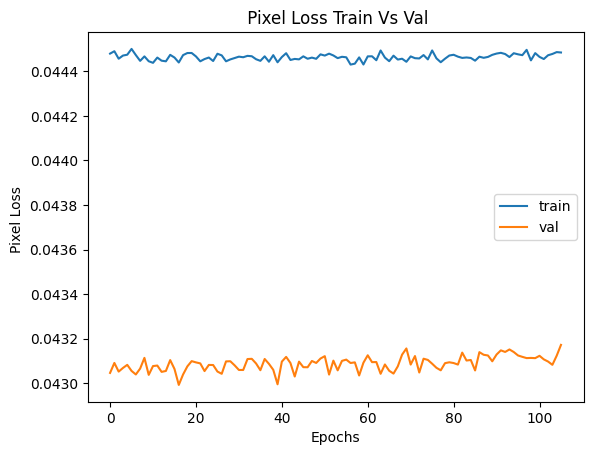

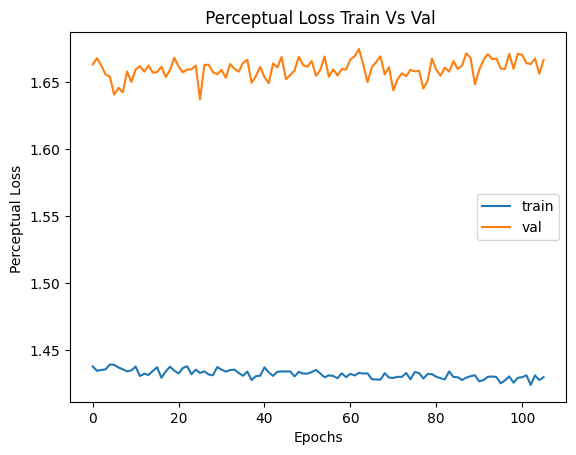

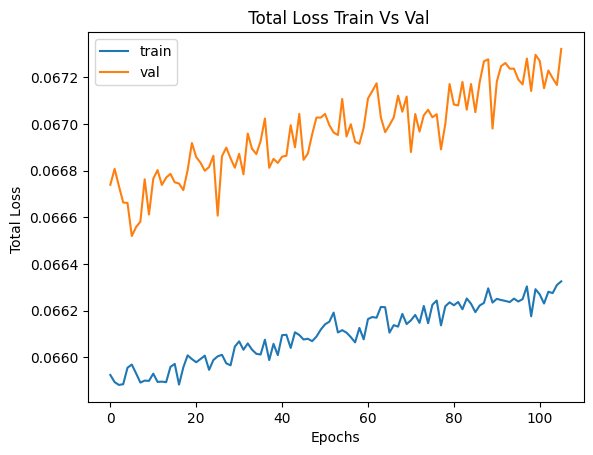

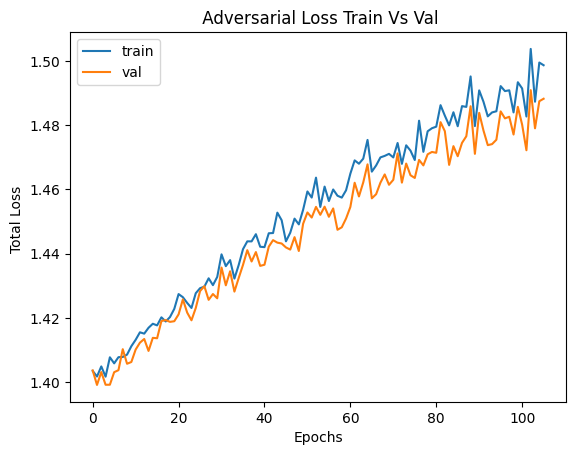

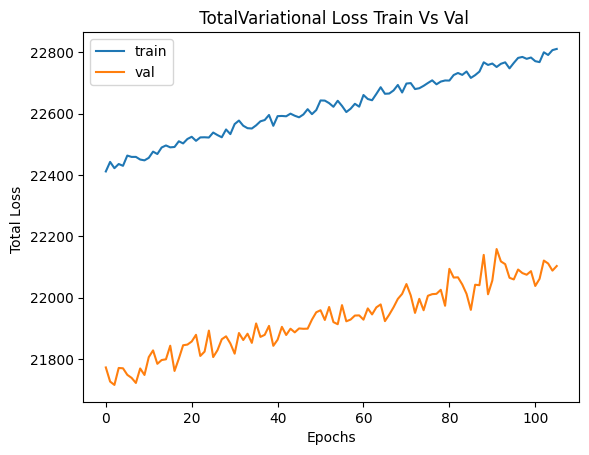

In [ ]:
plt.figure()
plt.plot(losses_pixel_train,label='train')
plt.plot(losses_pixel_val,label='val')
plt.legend()
plt.title(" Pixel Loss Train Vs Val")
plt.xlabel("Epochs")
plt.ylabel("Pixel Loss ")


plt.figure()
plt.plot(losses_perceptual_train,label='train')
plt.plot(losses_perceptual_val,label='val')
plt.legend()
plt.title(" Perceptual Loss Train Vs Val")
plt.xlabel("Epochs")
plt.ylabel("Perceptual Loss ")



plt.figure()
plt.plot(total_losses_RIR_G_train,label='train')
plt.plot(total_losses_RIR_G_val,label='val')
plt.legend()
plt.title(" Total Loss Train Vs Val")
plt.xlabel("Epochs")
plt.ylabel("Total Loss ")
plt.show()


plt.figure()
plt.plot(losses_adversarial_train,label='train')
plt.plot(losses_adversarial_val,label='val')
plt.legend()
plt.title(" Adversarial Loss Train Vs Val")
plt.xlabel("Epochs")
plt.ylabel("Total Loss ")
plt.show()


plt.figure()
plt.plot(losses_totalVariation_train,label='train')
plt.plot(losses_totalVariation_val,label='val')
plt.legend()
plt.title(" TotalVariational Loss Train Vs Val")
plt.xlabel("Epochs")
plt.ylabel("Total Loss ")
plt.show()

In [ ]:
# #* Saving the losses in the json file :


data = {
    "generator": {
        "train": {
            "total_losses_RIR_G_train": total_losses_RIR_G_train,
            "losses_pixel_train": losses_pixel_train,
            "losses_perceptual_train": losses_perceptual_train,
        },
        "val": {
            "total_losses_RIR_G_val": total_losses_RIR_G_val,
            "losses_pixel_val": losses_pixel_val,
            "losses_perceptual_val": losses_perceptual_val,
        },
    },
    "discriminator": {
        "train": {
            "losses_RaD_train": losses_RaD_train,
        },
        "val": {
            "losses_RaD_val": losses_RaD_val,
        },
    },
}

with open("./GAN2_110_Noise/GAN_all_losses_300.json", "w") as f:

    json.dump(data, f, indent=4)



# **Testing Images :**

In [47]:
gen=RIRG(
    in_channel=3,
    out_channel=3,
    in_RIR_block_channel=64,
    kernel_size_in_out_layer=9,
    kerne_size_RIR_block=3,
    no_of_RIR_Block=8,
    no_of_ERes_block=5,
    sub_PixelLayer_channel=256,
    alpha=0.2,
    scale=2   
)

gen.load_state_dict(torch.load('./GAN2_110_Noise/GAN_generator2_noise_200.pth'))


<All keys matched successfully>

In [48]:
LR_Images,HR_Images=next(iter(test_loader))
print(f'Shape of Batch Test LR_Images :{LR_Images.shape}')
print(f'Shape of Batch Test HR_Images :{HR_Images.shape}')

Shape of Batch Test LR_Images :torch.Size([16, 3, 32, 32])
Shape of Batch Test HR_Images :torch.Size([16, 3, 128, 128])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12187634..0.87514716].


<Figure size 640x480 with 0 Axes>

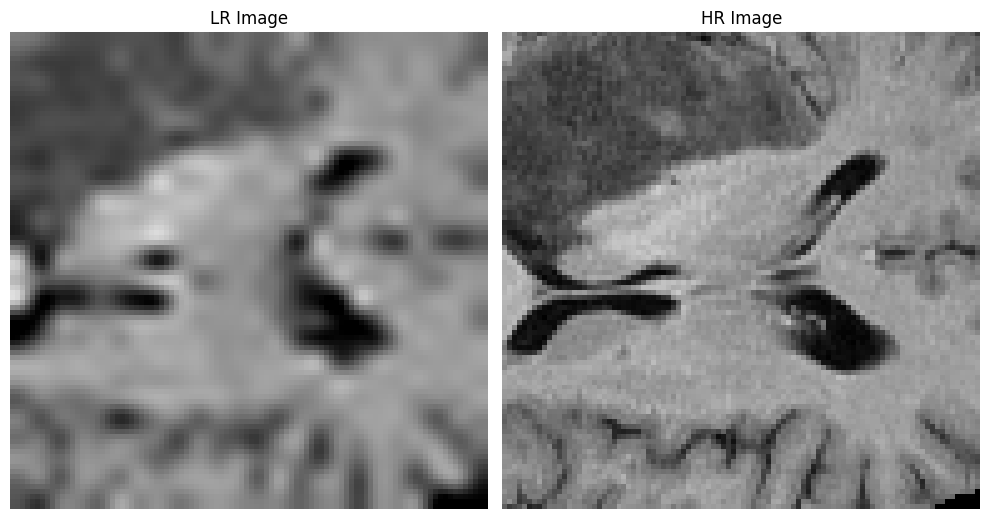

In [ ]:
show_MRI_images(
    image1=(LR_image+1)/2,
    image2=(HR_image+1)/2,
    title1='LR Image',
    title2='HR Image'
)

In [ ]:
# #* loop for storing the Test Images int th folder Test_Images :
device=torch.device('cuda')
gen=gen.to(device)
name=1
for LR_Images,HR_Images in test_loader:
    
    with torch.no_grad():
        LR_Images,HR_Images=LR_Images.to(device),HR_Images.to(device)
        SR_Images=gen(LR_Images)
        
        for index, SR_Image in enumerate(SR_Images):

            LR_Image=LR_Images[index]
            HR_Image=HR_Images[index]

            SR_Image,LR_Image,HR_Image=SR_Image.to('cpu'),LR_Image.to('cpu'),HR_Image.to('cpu')   
            save_MRI_images(
                (LR_Image + 1) / 2,
                (SR_Image + 1) / 2,
                (HR_Image + 1) / 2,
                title1="LR",
                title2="SR",
                title3="HR",
                image_name=f"/{name}.png",
                fold="GAN_Testing_Images2_NOISE",
            )
            name+=1


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.060274757..0.7803972].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.10043769..0.7176721].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.07944339..0.66274613].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.06964602..0.82912415].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0789814..0.6470609].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.107790254..0.71373].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0

# **Evaluation Metrics**

## **PSNR** 
    - (ie.for single image)

In [49]:
def PSNR(SR_Images,HR_Images):

    SR_Images=(SR_Images+1)/2
    HR_Images=(HR_Images+1)/2
    C,H,W=SR_Images[0].shape
    total_pixel_per_image=C*H*W
    psnr=10*torch.log10(((1/(((HR_Images-SR_Images)**2).sum(dim=(1,2,3))/(total_pixel_per_image)))))

    return np.array(psnr)


## **SSIM :**

In [51]:
def SSIM(SR_Images,HR_Images,K1:float,K2: float):

    B,C,H,W=SR_Images.shape
    Ux=SR_Images.mean(dim=(1,2,3),keepdim=True).reshape(B,1)
    Uy=HR_Images.mean(dim=(1,2,3),keepdim=True).reshape(B,1)
    
    (Xi_X)=SR_Images-(SR_Images.mean(dim=(1,2,3),keepdim=True))
    (Yi_Y)=HR_Images-(HR_Images.mean(dim=(1,2,3),keepdim=True))

    covar_x_y=((Xi_X*Yi_Y).sum(dim=(1,2,3))/(C*H*W)).reshape(B,1)

    var_x=(Xi_X**2).mean(dim=(1,2,3),keepdim=True).reshape(B,1)
    var_y=(Yi_Y**2).mean(dim=(1,2,3),keepdim=True).reshape(B,1)

    term1=((Ux*Uy*2) + K1)/((Ux**2) + (Uy**2) + K1)

    term2=(covar_x_y + K2)/(var_x +var_y + K2 ) 

    ssim=(term1*term2).reshape(B) 

    return np.array(ssim)


In [53]:
test_dataset.__len__()

3050

In [52]:
# #* finding the statistical parameter of Images to find the image quality
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gen=gen.to(device)


psnr_list=np.array([])
ssim_list=np.array([])

for LR_Images,HR_Images in test_loader:

    LR_Images,HR_Images=LR_Images.to(device),HR_Images.to(device)
    with torch.no_grad():
        SR_Images=gen(LR_Images)

    #* find the psnr of each images and append to psnr list :

    SR_Images,HR_Images=SR_Images.to('cpu'),HR_Images.to('cpu')
    psnr_list_temp=PSNR(SR_Images,HR_Images)
    ssim_list_temp=SSIM(SR_Images,HR_Images,0.01,0.02)

    psnr_list=np.append(psnr_list,psnr_list_temp)

    ssim_list=np.append(ssim_list,ssim_list_temp)
    

In [ ]:
Mean=psnr_list.mean()
Var=psnr_list.var()
Std=psnr_list.std()
Min=psnr_list.min()
Max=psnr_list.max()
delta=Max-Min

print("*"*25)
print( "RIRGAN_Metric_PSNR :")
print(f" Mean  ↑ : {Mean:.2f}")
print(f' Var   ↓ : {Var:.2f}')
print(f' Std   ↓ : {Std:.2f}')
print(f' Min   - : {Min:.2f}')
print(f' Max   - : {Max:.2f}')
print(f' Delta ↓ : {delta:.2f}')



Mean=ssim_list.mean()
Var=ssim_list.var()
Std=ssim_list.std()
Min=ssim_list.min()
Max=ssim_list.max()
delta=Max-Min


print("*"*25)
print( "RIRGAN_Metric_SSIM :")
print(f" Mean  ↑ : {Mean:.5f}")
print(f' Var   ↓ : {Var:.5f}')
print(f' Std   ↓ : {Std:.5f}')
print(f' Min   - : {Min:.5f}')
print(f' Max   - : {Max:.5f}')
print(f' Delta ↓ : {delta:.5f}')

print("*"*25) 



*************************
RIRGAN_Metric_PSNR :
 Mean  ↑ : 27.85
 Var   ↓ : 3.63
 Std   ↓ : 1.91
 Min   - : 21.87
 Max   - : 33.47
 Delta ↓ : 11.60
*************************
RIRGAN_Metric_SSIM :
 Mean  ↑ : 0.53570
 Var   ↓ : 0.00042
 Std   ↓ : 0.02057
 Min   - : 0.49489
 Max   - : 0.68601
 Delta ↓ : 0.19113
*************************
